In [1]:
import numpy as np

def compute_instrumental_profile(R=3000, pixel_spacing=1e-4, width=3):
    """
    Compute normalized Gaussian instrumental profile kernel.

    Parameters
    ----------
    R : float
        Spectrograph resolving power (lambda / delta_lambda). Default is 3000 for DESI.
    pixel_spacing : float
        Pixel spacing in log10(lambda). Default is 1e-4 for DESI.
    width : int
        Half-width of the kernel in pixels. Total kernel size = 2*width + 1.

    Returns
    -------
    profile : np.ndarray
        Normalized 1D Gaussian kernel of shape (2 * width + 1,).
    pixel_sigma : float
        Standard deviation of the Gaussian in pixel units.
    """
    # Compute sigma in pixel units
    pixel_sigma = 1 / (R * 2 * np.sqrt(2 * np.log(2)) * (10**pixel_spacing - 1))

    # Create kernel centered at 0, with 2*width + 1 points
    offsets = np.arange(-width, width + 1)
    profile = np.exp(-0.5 * (offsets / pixel_sigma)**2)

    # Normalize the kernel
    profile /= np.sum(profile)

    return profile, pixel_sigma

In [8]:
profile, sigma = compute_instrumental_profile(R=3000)
profile_2000, sigma_2000 = compute_instrumental_profile(R=2000)

np.savetxt("../data/dr12q/processed/desi_instrumental_profile_R3000.txt", profile)

print(f"Pixel sigma = {sigma:.3f}")
print("Instrumental kernel:", profile)

Pixel sigma = 0.615
Instrumental kernel: [4.35938200e-06 3.25792567e-03 1.72604025e-01 6.48267379e-01
 1.72604025e-01 3.25792567e-03 4.35938200e-06]


In [3]:
from matplotlib import pyplot as plt

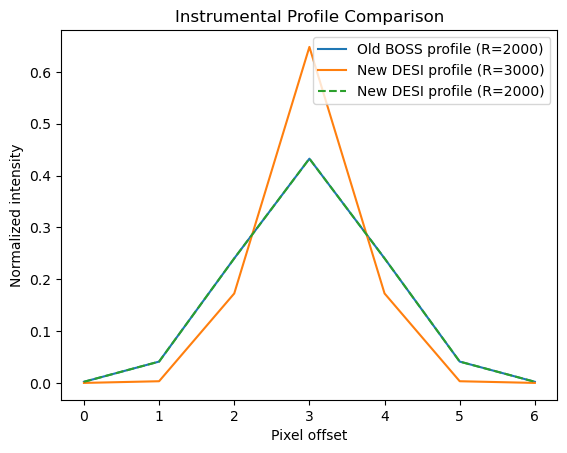

In [6]:
old_profile = [
    2.17460992138080811e-03,
    4.11623059580451742e-02,
    2.40309364651846963e-01,
    4.32707438937454059e-01, 
    2.40309364651846963e-01,
    4.11623059580451742e-02,
    2.17460992138080811e-03
]

plt.plot(old_profile, label="Old BOSS profile (R=2000)")
plt.plot(profile, label="New DESI profile (R=3000)")
plt.plot(profile_2000, label="New DESI profile (R=2000)", linestyle='--')
plt.legend()
plt.xlabel("Pixel offset")
plt.ylabel("Normalized intensity")
plt.title("Instrumental Profile Comparison")
plt.show()